# Multiclass feature importance


In [3]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import os

RESULTS_DIR = os.path.join(os.pardir, "results", "reports")
TRANSFORMER_MULTICLASS_DIR = os.path.join(RESULTS_DIR, "transformer", "multiclass")
LSTM_MULTICLASS_DIR = os.path.join(RESULTS_DIR, "lstm", "multiclass")

TRANSFORMER_SHAP_VALUES = os.path.join(TRANSFORMER_MULTICLASS_DIR, "with_network_specific_features", "45_epochs", 
                                        "shap_values_transformer_cybersecurity-unified-multiclass.csv")
TRANSFORMER_UNI_REMOVED_SHAP_VALUES = os.path.join(TRANSFORMER_MULTICLASS_DIR, "unified_removed_features", "45_epochs", 
                                        "shap_values_transformer_cybersecurity-unified-multiclass_removed.csv")
TRANSFORMER_SEP_REMOVED_SHAP_VALUES = os.path.join(TRANSFORMER_MULTICLASS_DIR, "separate_removed_features", "45_epochs", 
                                        "shap_values_transformer_cybersecurity-unified-multiclass_removed.csv")

LSTM_SHAP_VALUES = os.path.join(LSTM_MULTICLASS_DIR, "with_network_specific_features", "10_epochs", "shap_values_lstm_cybersecurity-unified-multiclass.csv")
LSTM_UNI_REMOVED_SHAP_VALUES = os.path.join(LSTM_MULTICLASS_DIR, "unified_removed_features", "10_epochs", 
                                        "shap_values_lstm_cybersecurity-unified-multiclass_removed.csv")
LSTM_SEP_REMOVED_SHAP_VALUES = os.path.join(LSTM_MULTICLASS_DIR, "separate_removed_features", "10_epochs", 
                                        "shap_values_lstm_cybersecurity-unified-multiclass_removed.csv")

MALWARE_CATEGORIES = ["Botnet", "DoS", "MITM", "Normal", "Scanner", "Brute force", "Generic", "Exploit", "Infection"]
N_MALWARE_CATEGORIES = len(MALWARE_CATEGORIES)
COLORS = mpl.colormaps["jet"](np.linspace(0,1,N_MALWARE_CATEGORIES))

def plot_shap_values(df: pd.DataFrame, title: str, n_features=6):
    minmaxscaler = MinMaxScaler()
    fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(25,16), dpi=250)
    axs: list[plt.Axes] = axs.flatten()
    for i, category in enumerate(MALWARE_CATEGORIES):
        df = df.sort_values(category, ascending=False)
        features = df["Feature"]
        norm_shap_values = minmaxscaler.fit_transform(df[category].to_numpy().reshape(-1,1)).flatten()
        axs[i].bar(features[:n_features], norm_shap_values[:n_features], color=COLORS[i])
        axs[i].set_title(category)
        axs[i].tick_params(axis="x", labelrotation=15)
    fig.suptitle(title, fontsize=30)
    fig.subplots_adjust(hspace=0.3)
    fig.savefig("plot.pdf", bbox_inches="tight")


## Transformer
### All network specific features included

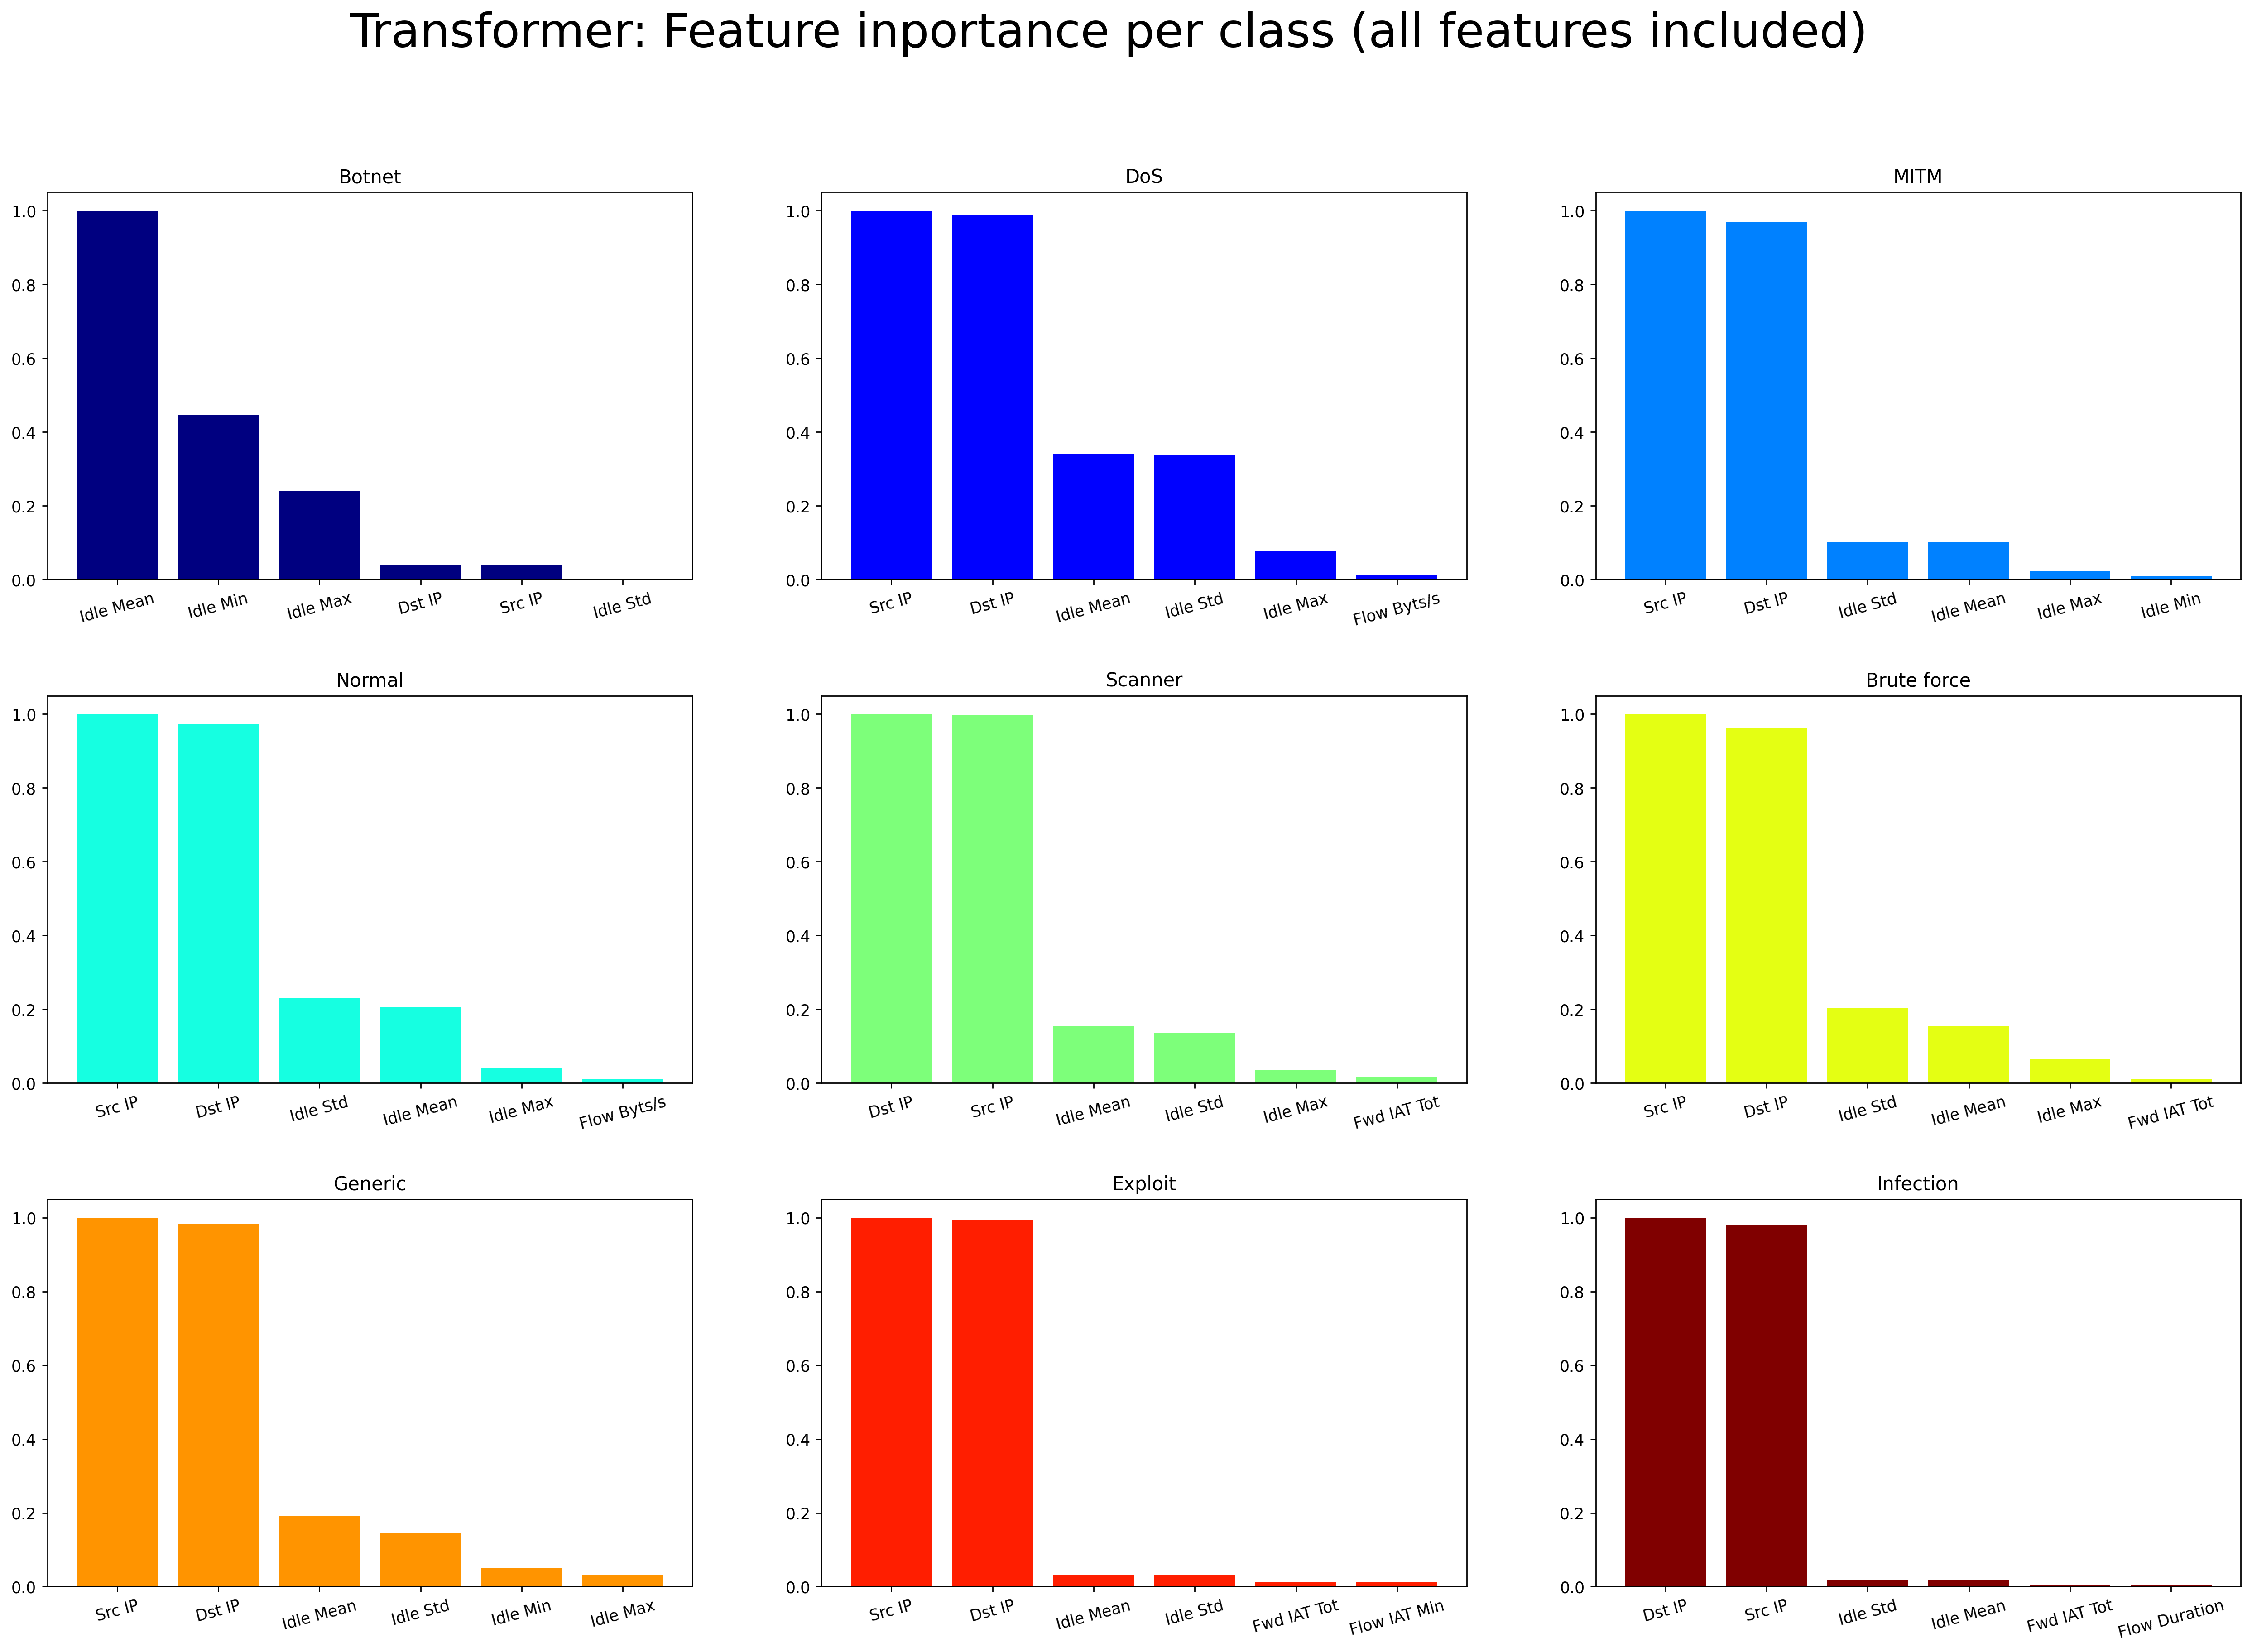

In [4]:
plot_shap_values(pd.read_csv(TRANSFORMER_SHAP_VALUES), "Transformer: Feature inportance per class (all features included)")

### Unified removed features

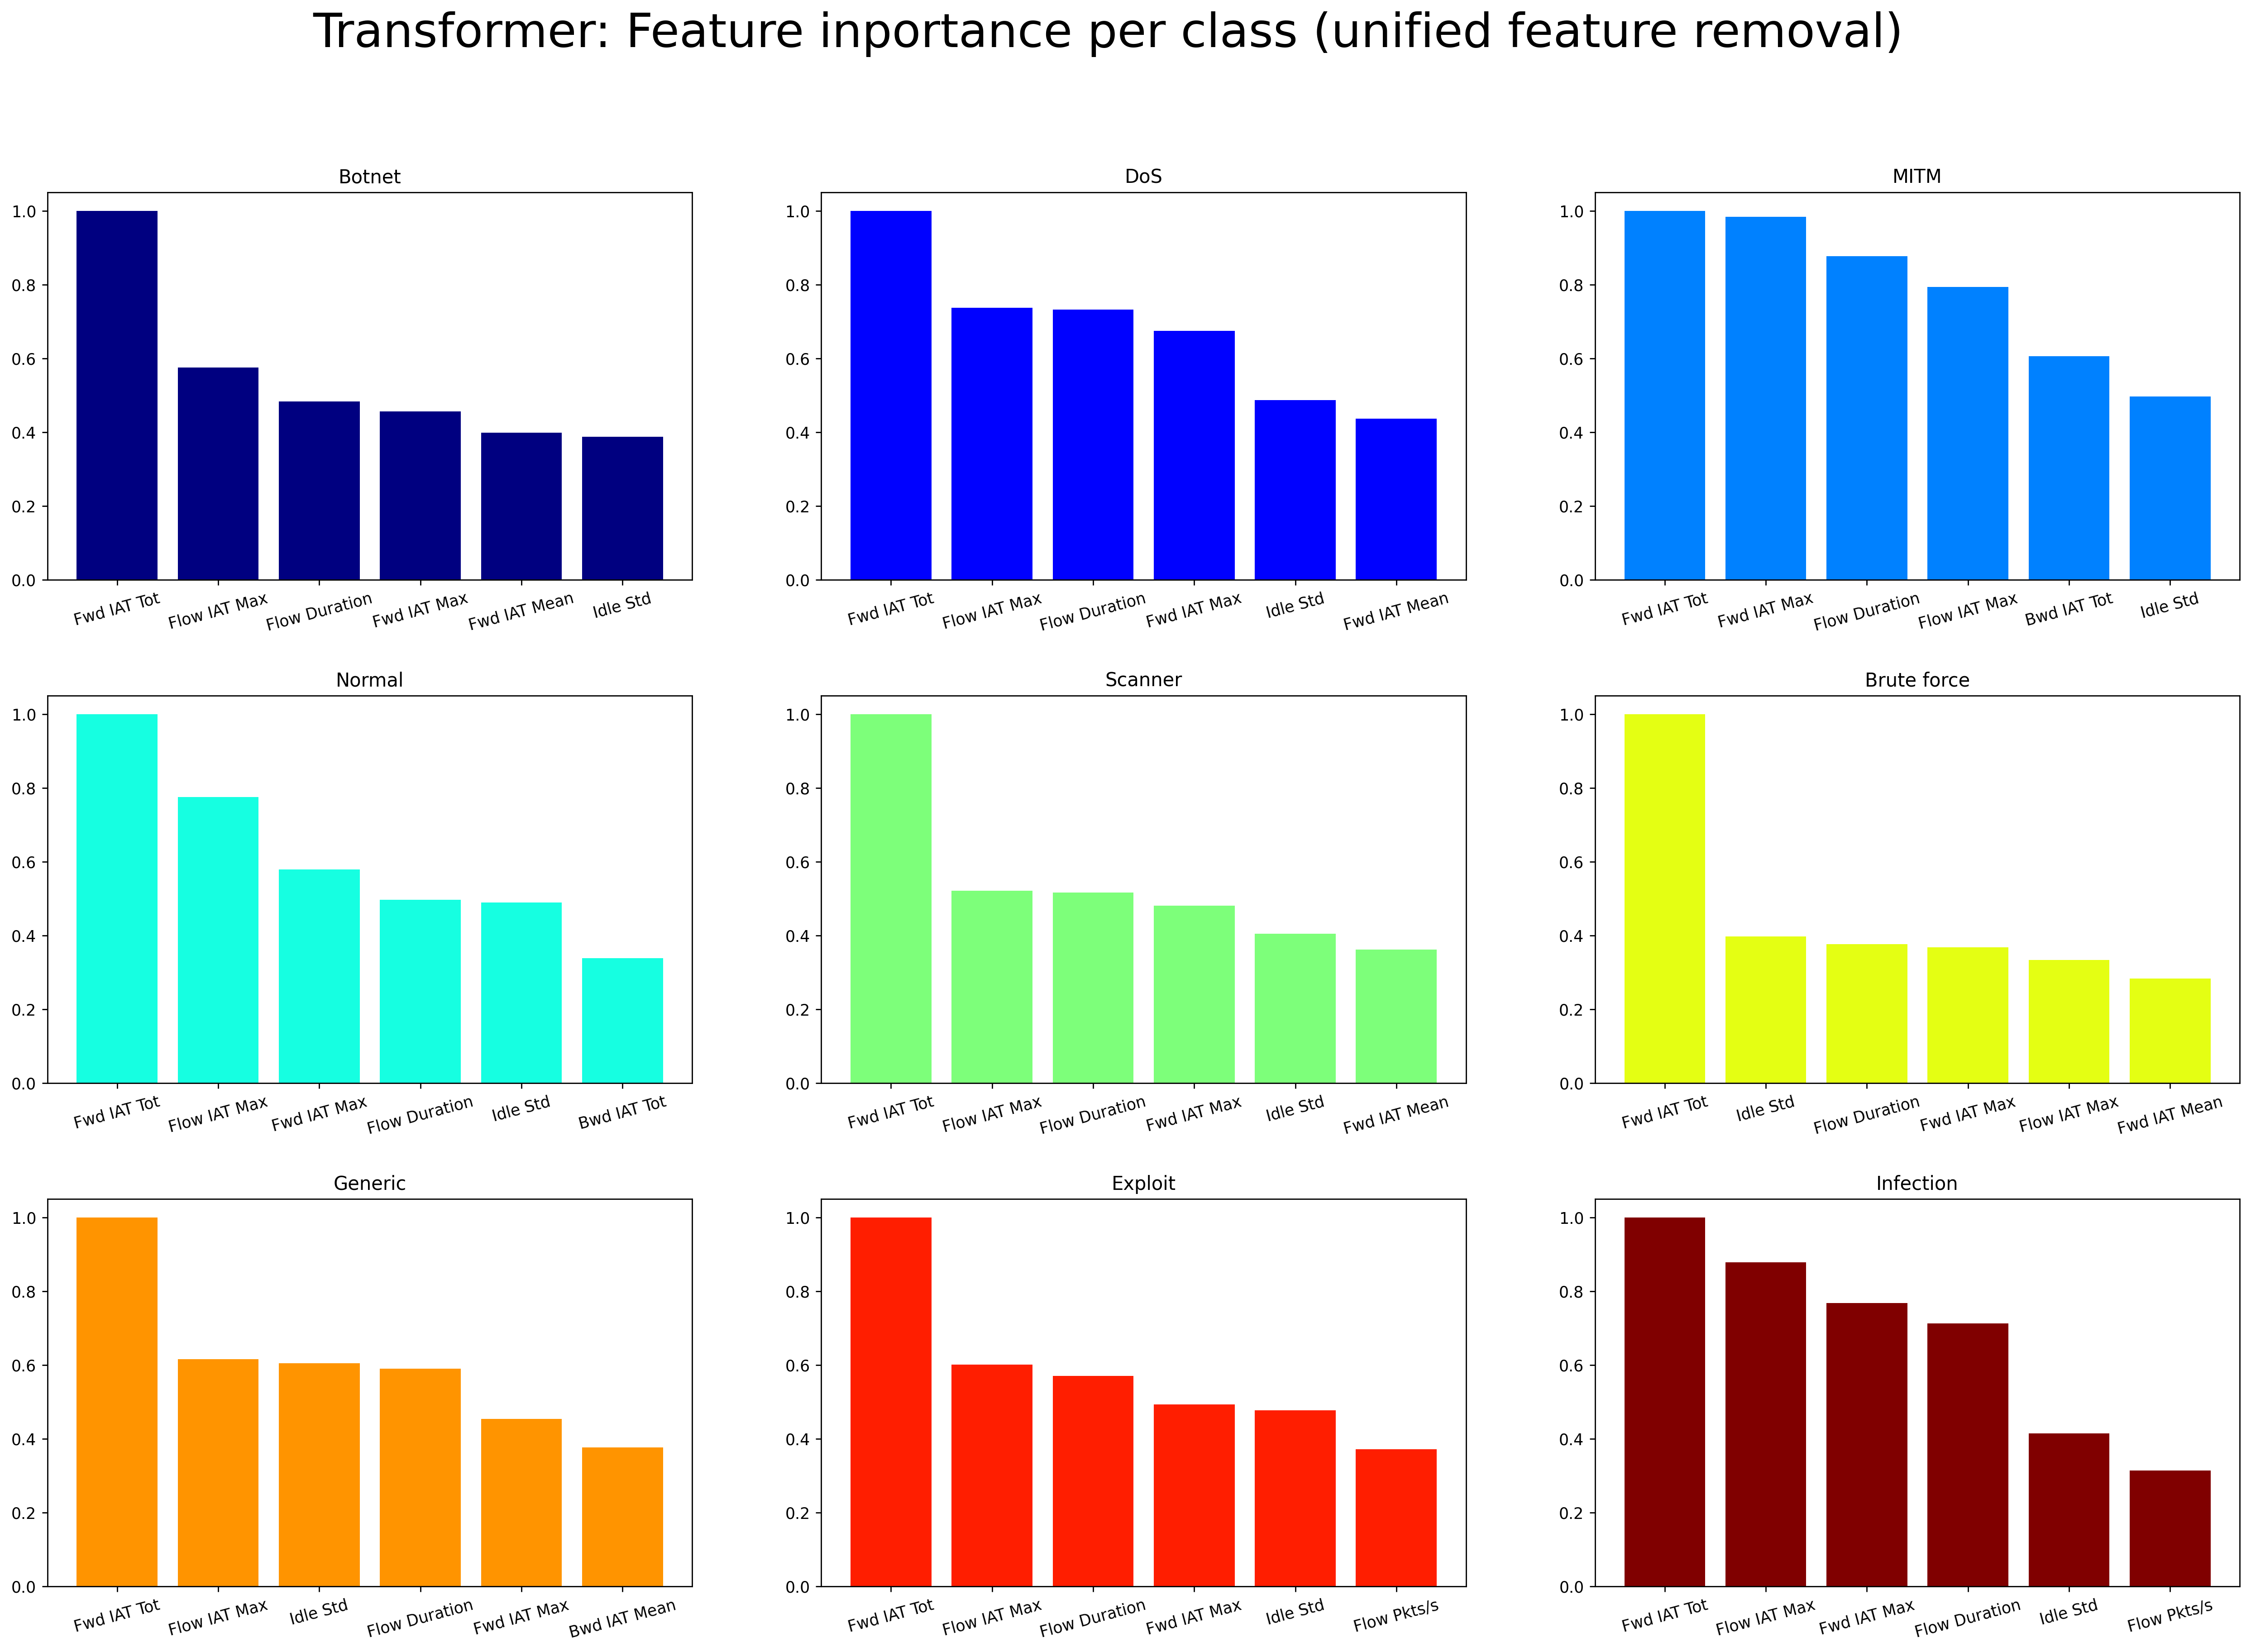

In [5]:
plot_shap_values(pd.read_csv(TRANSFORMER_UNI_REMOVED_SHAP_VALUES), "Transformer: Feature inportance per class (unified feature removal)")

### Separate removed features

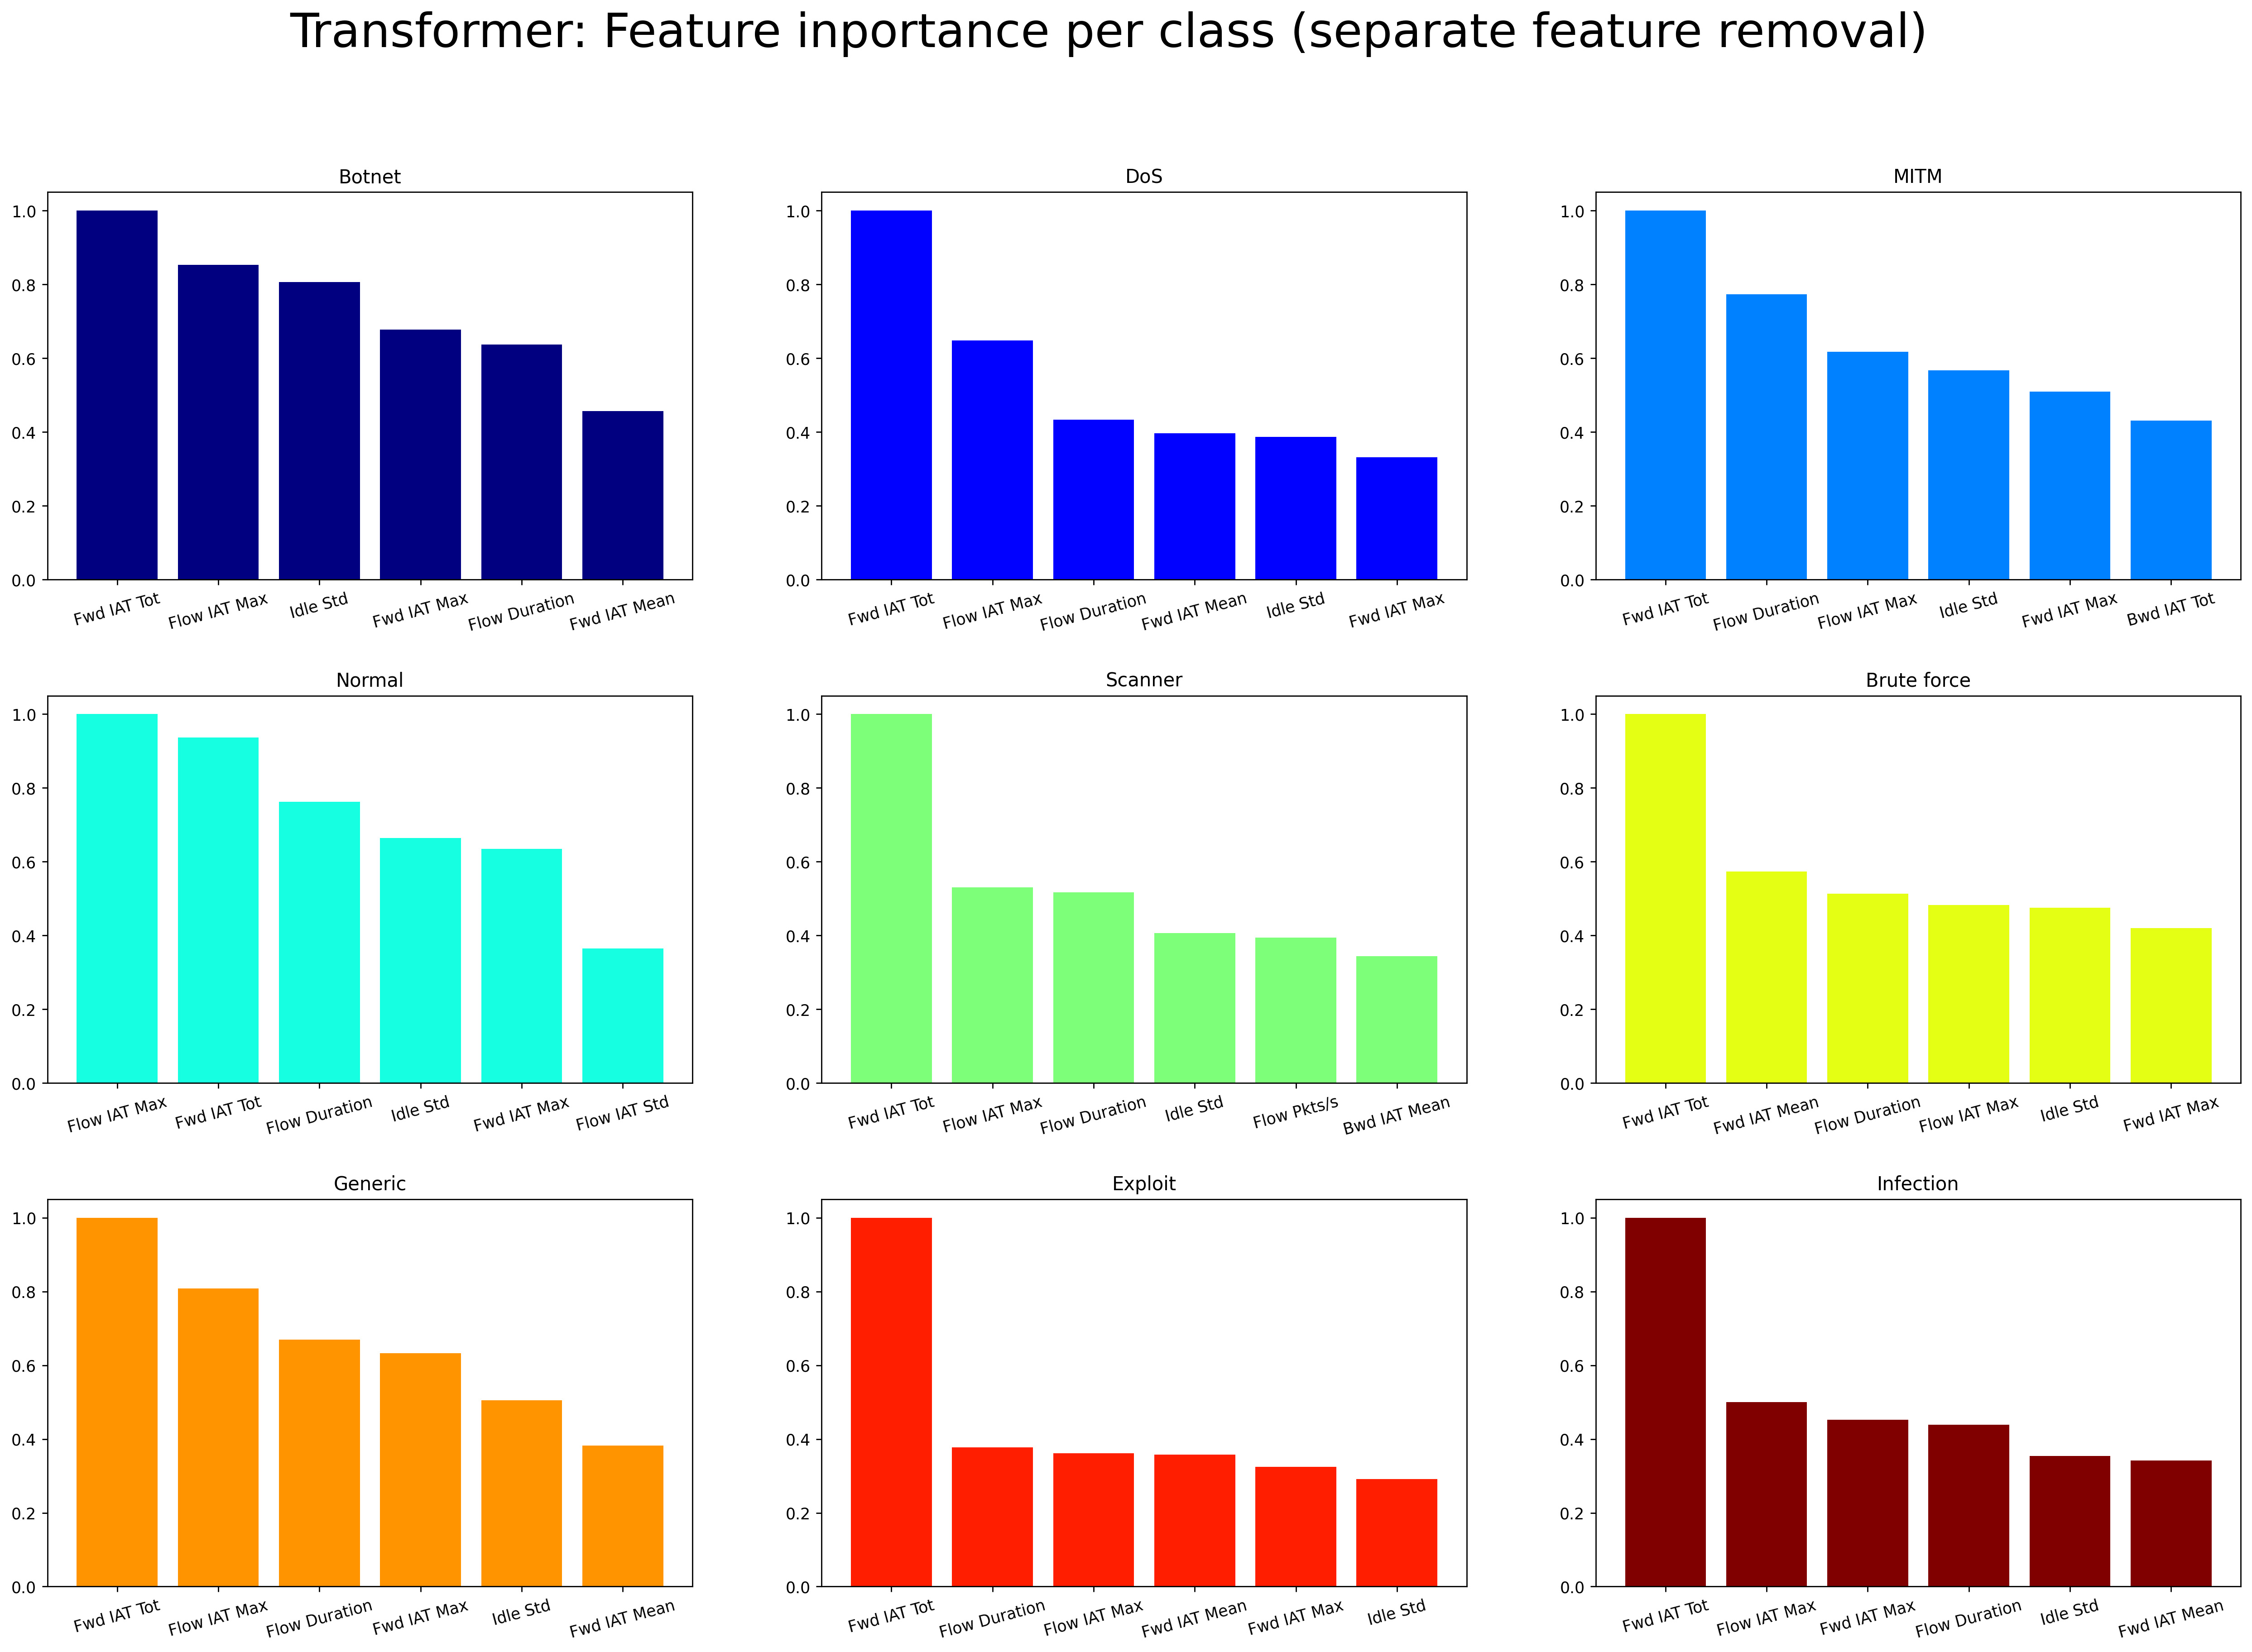

In [6]:
plot_shap_values(pd.read_csv(TRANSFORMER_SEP_REMOVED_SHAP_VALUES), "Transformer: Feature inportance per class (separate feature removal)")

## LSTM
### All network specific features included

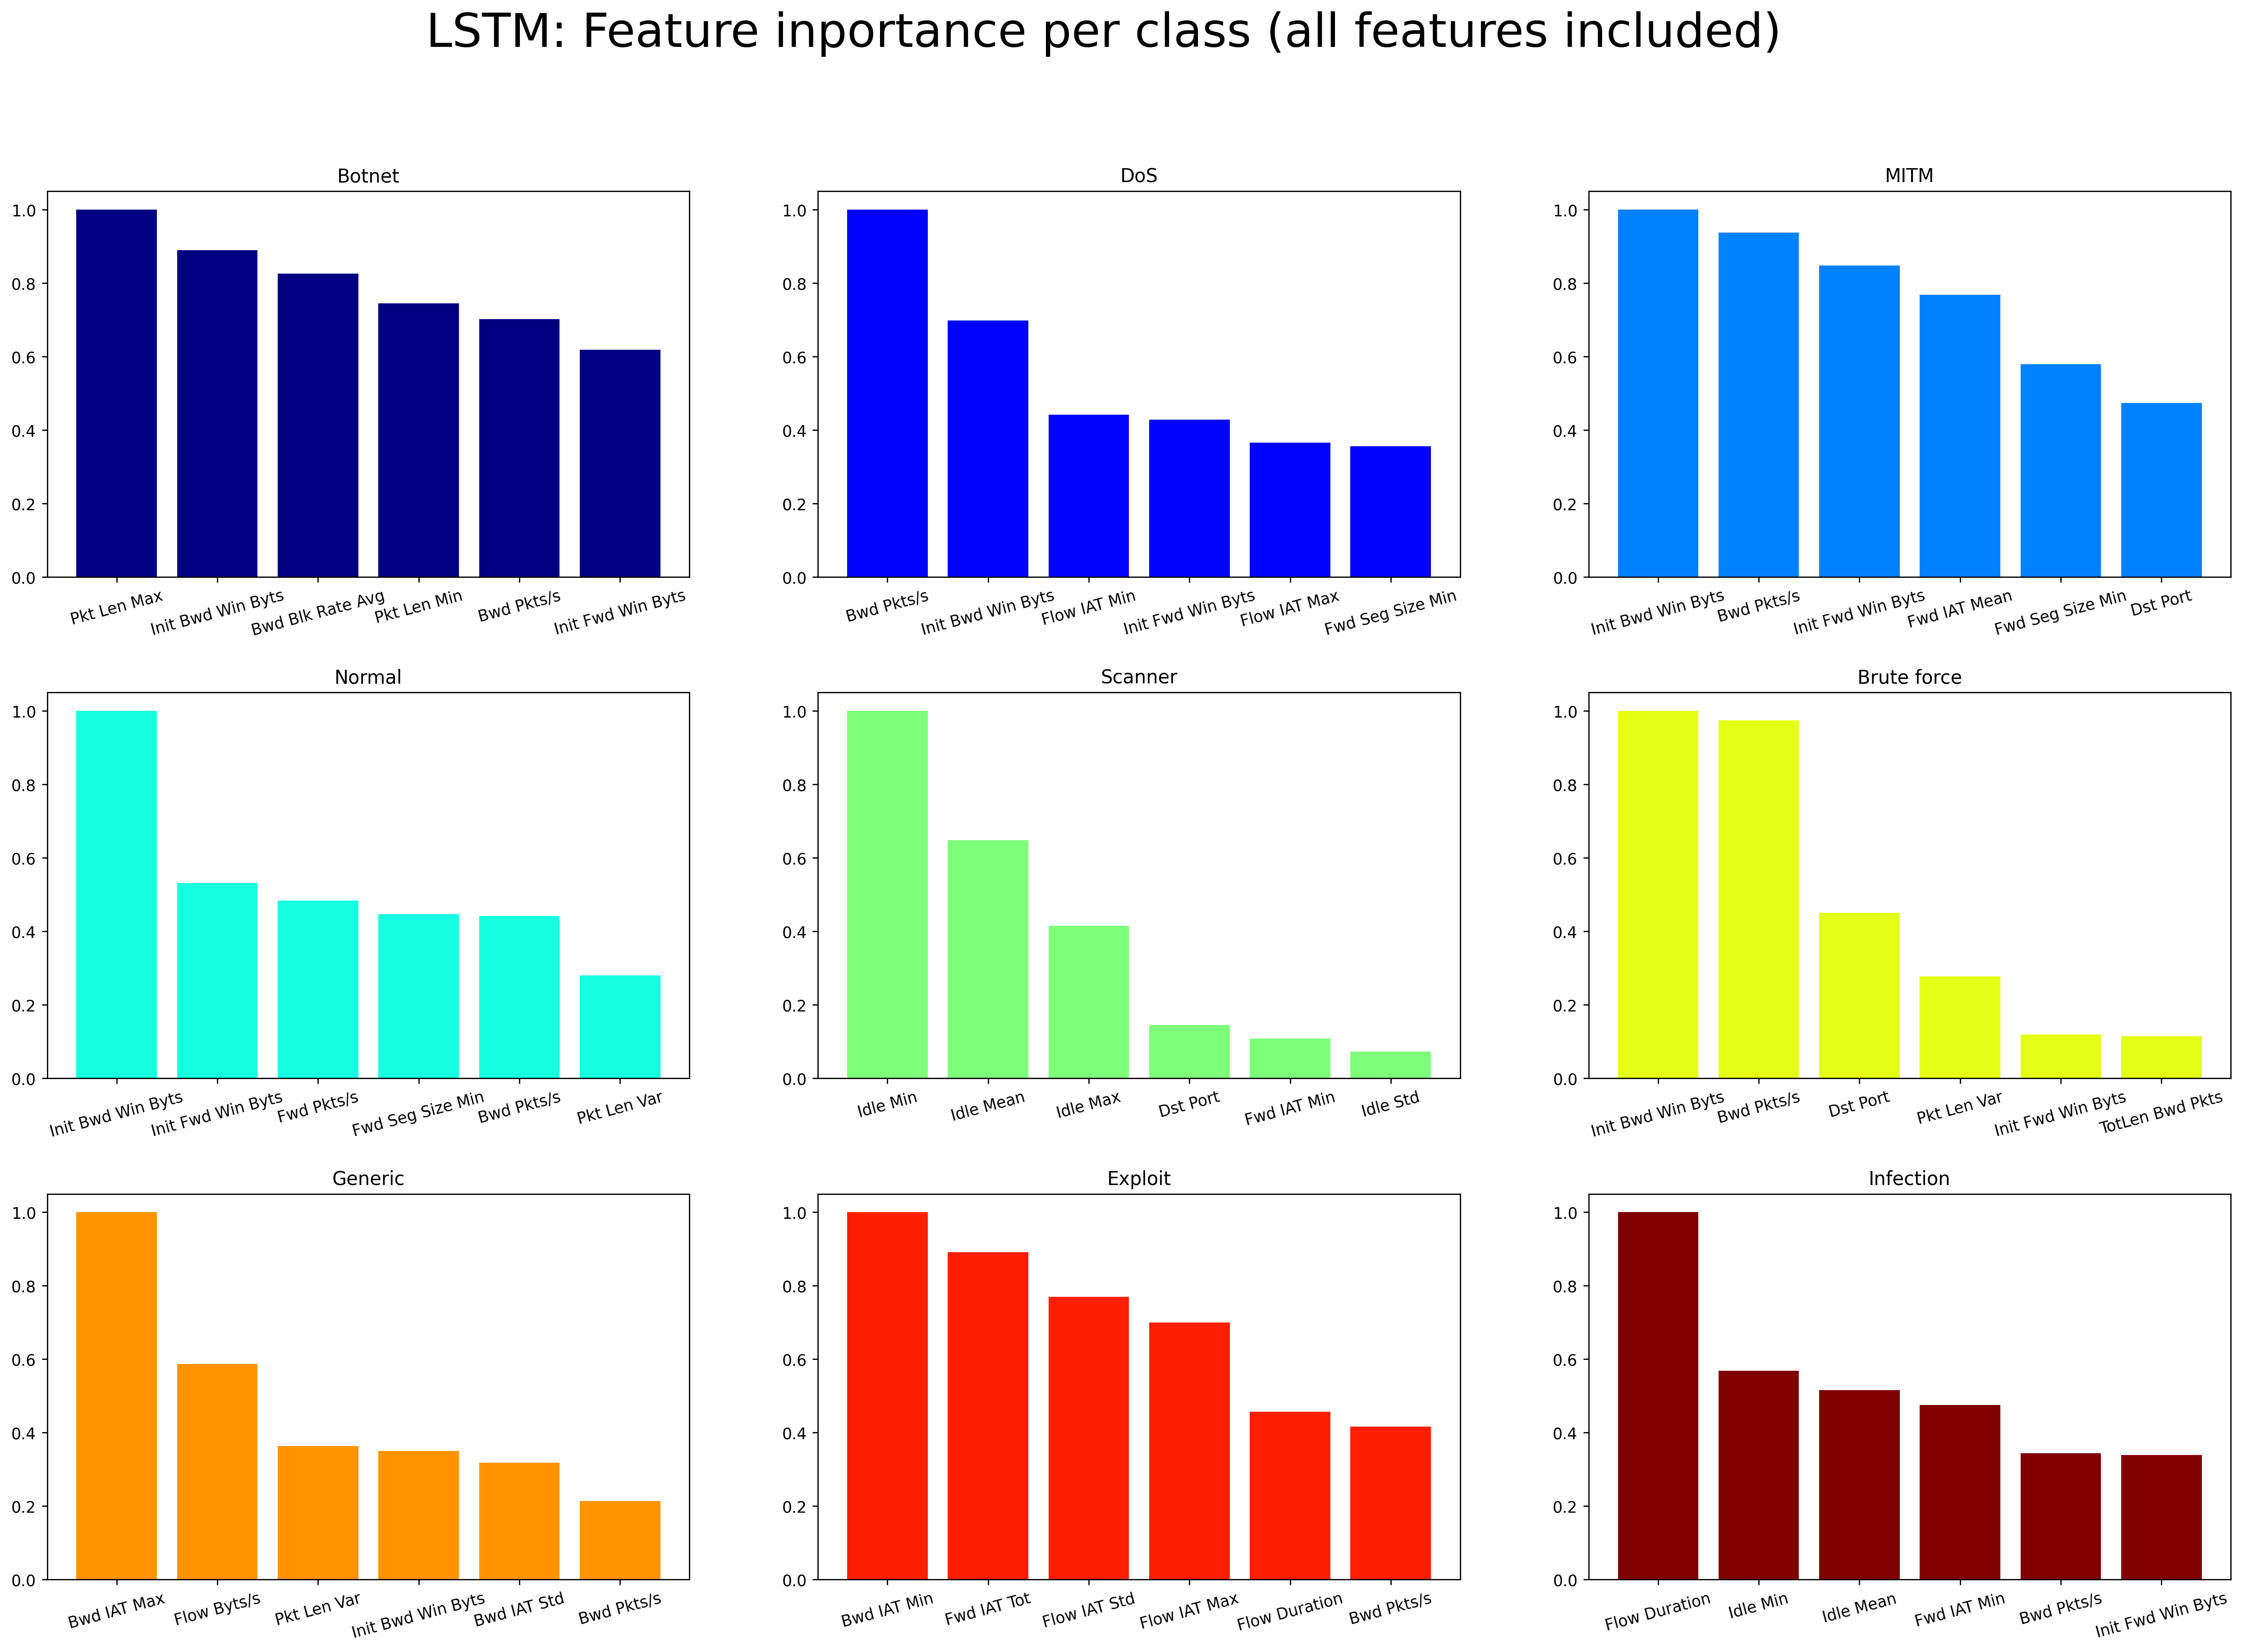

In [7]:
plot_shap_values(pd.read_csv(LSTM_SHAP_VALUES), "LSTM: Feature inportance per class (all features included)")

### Unified removed features

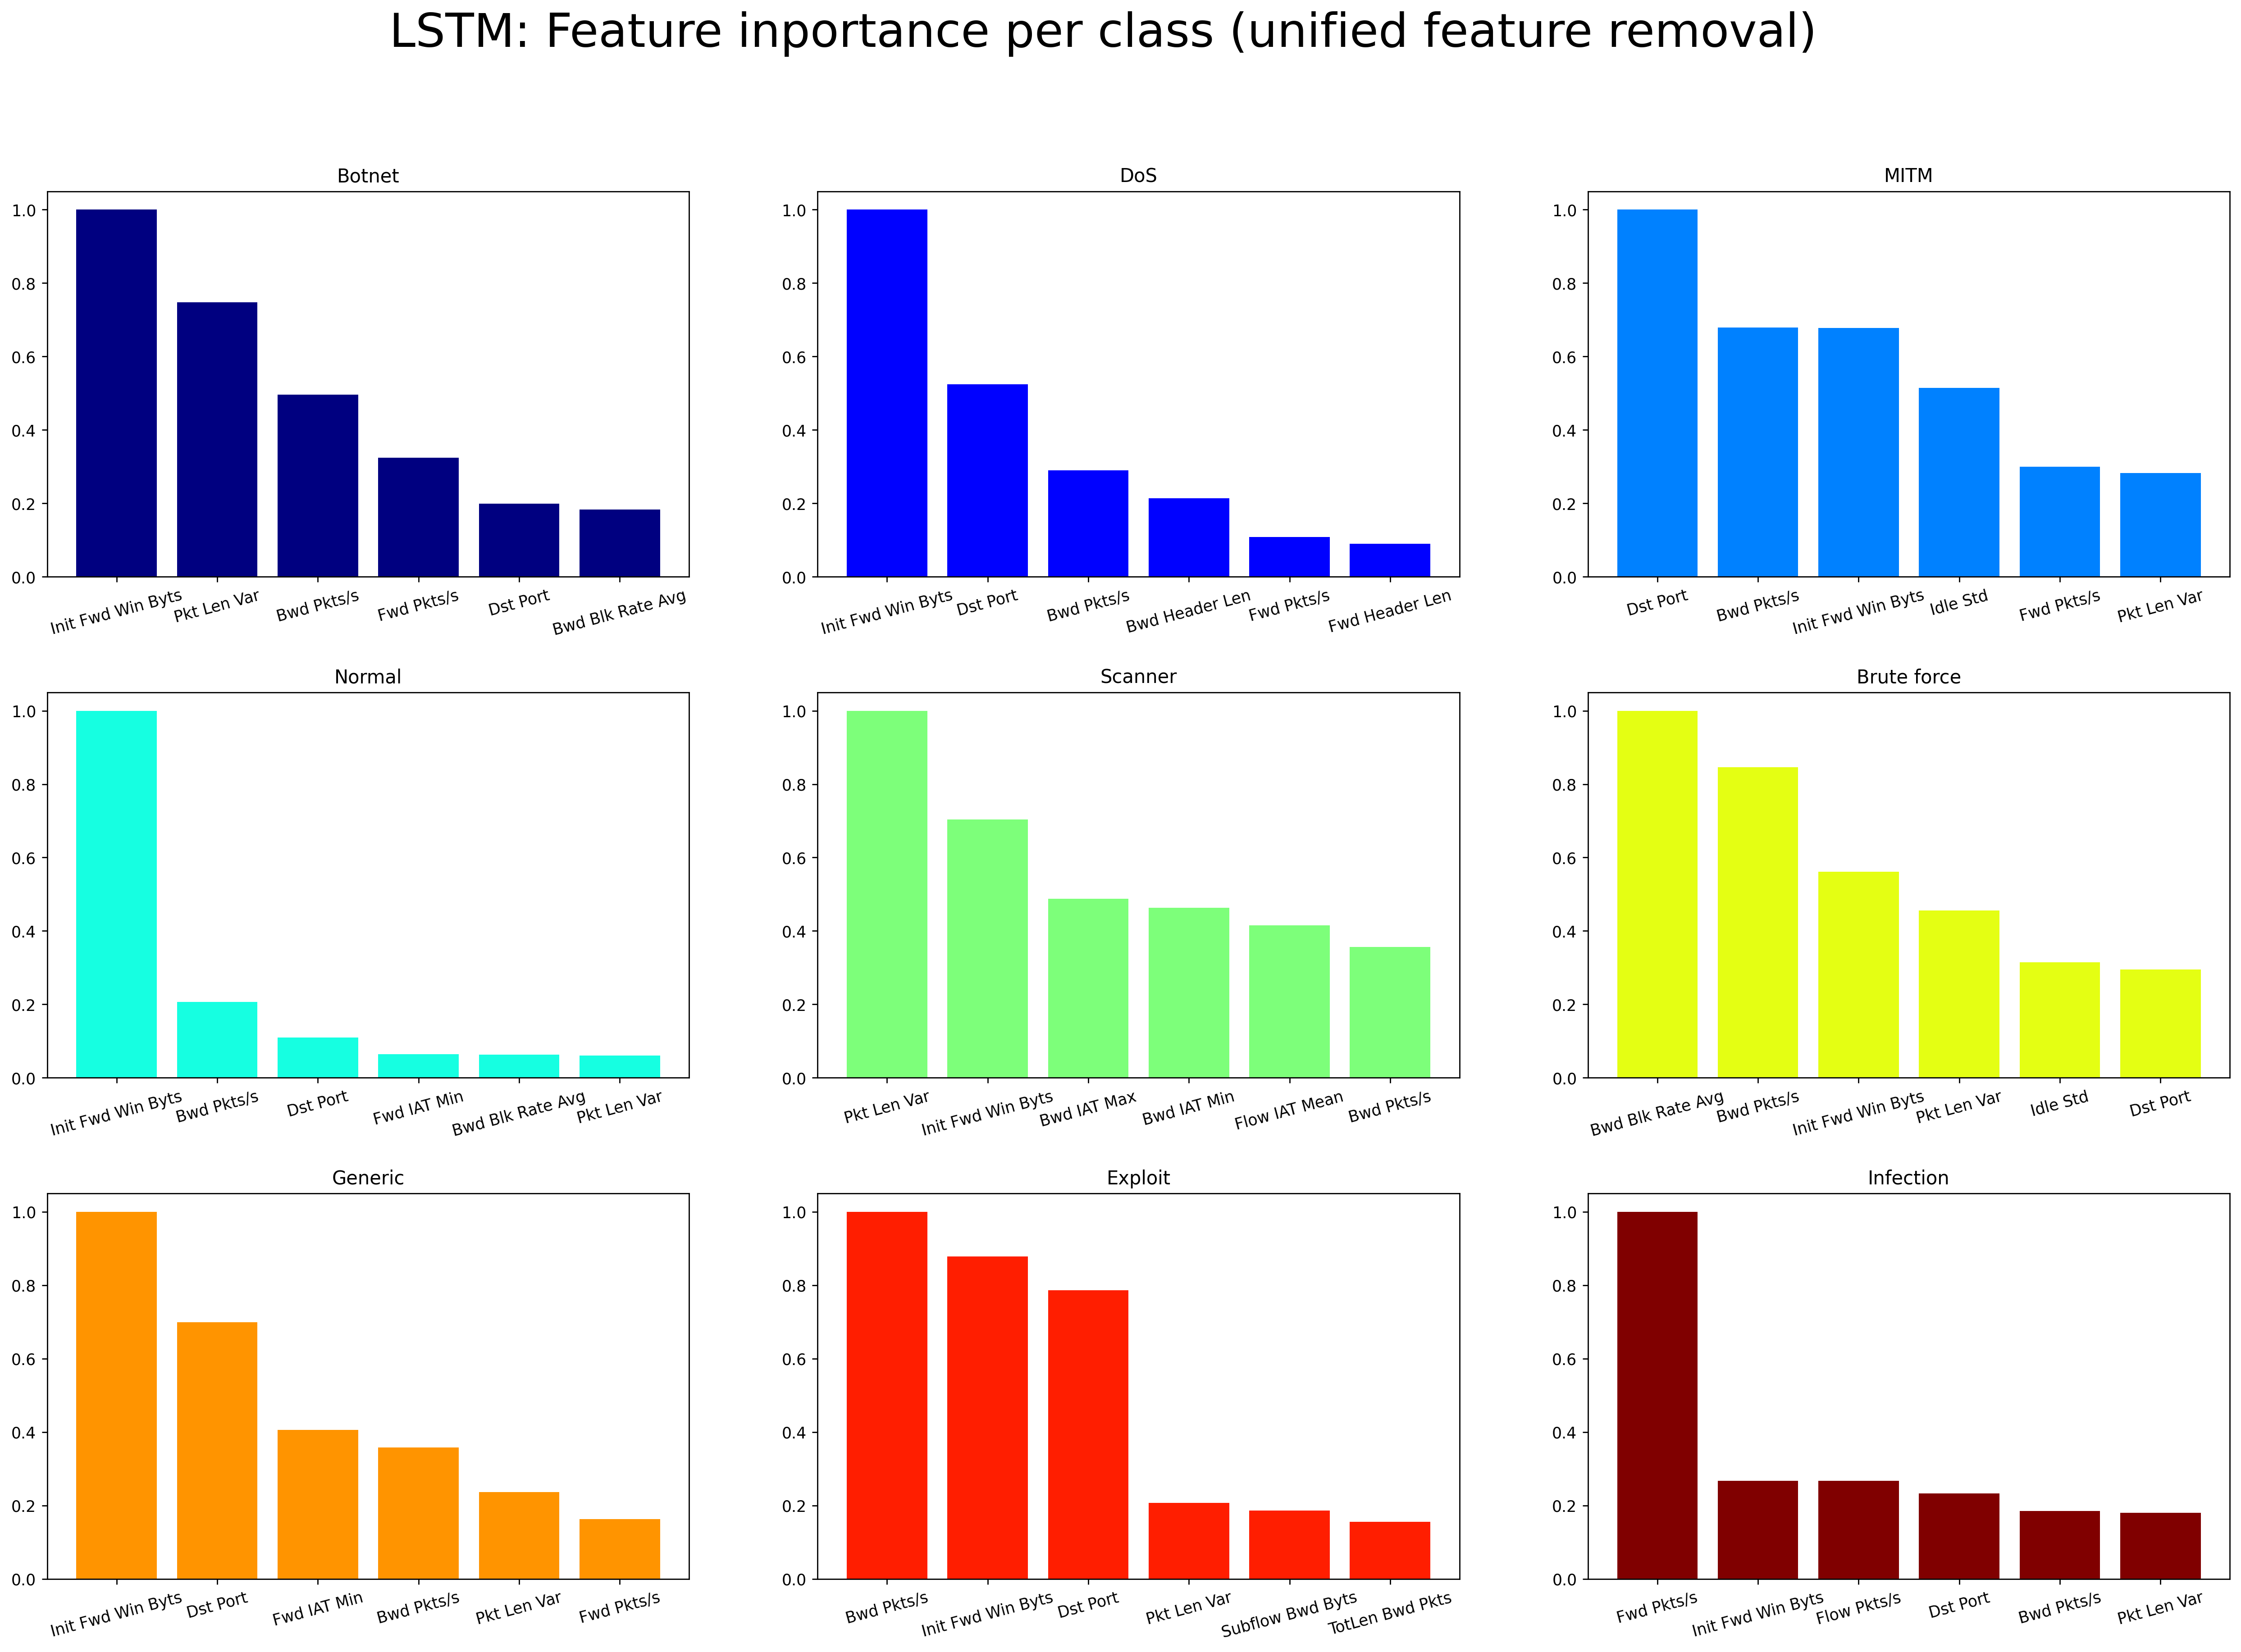

In [8]:
plot_shap_values(pd.read_csv(LSTM_UNI_REMOVED_SHAP_VALUES), "LSTM: Feature inportance per class (unified feature removal)")

### Separate removed features

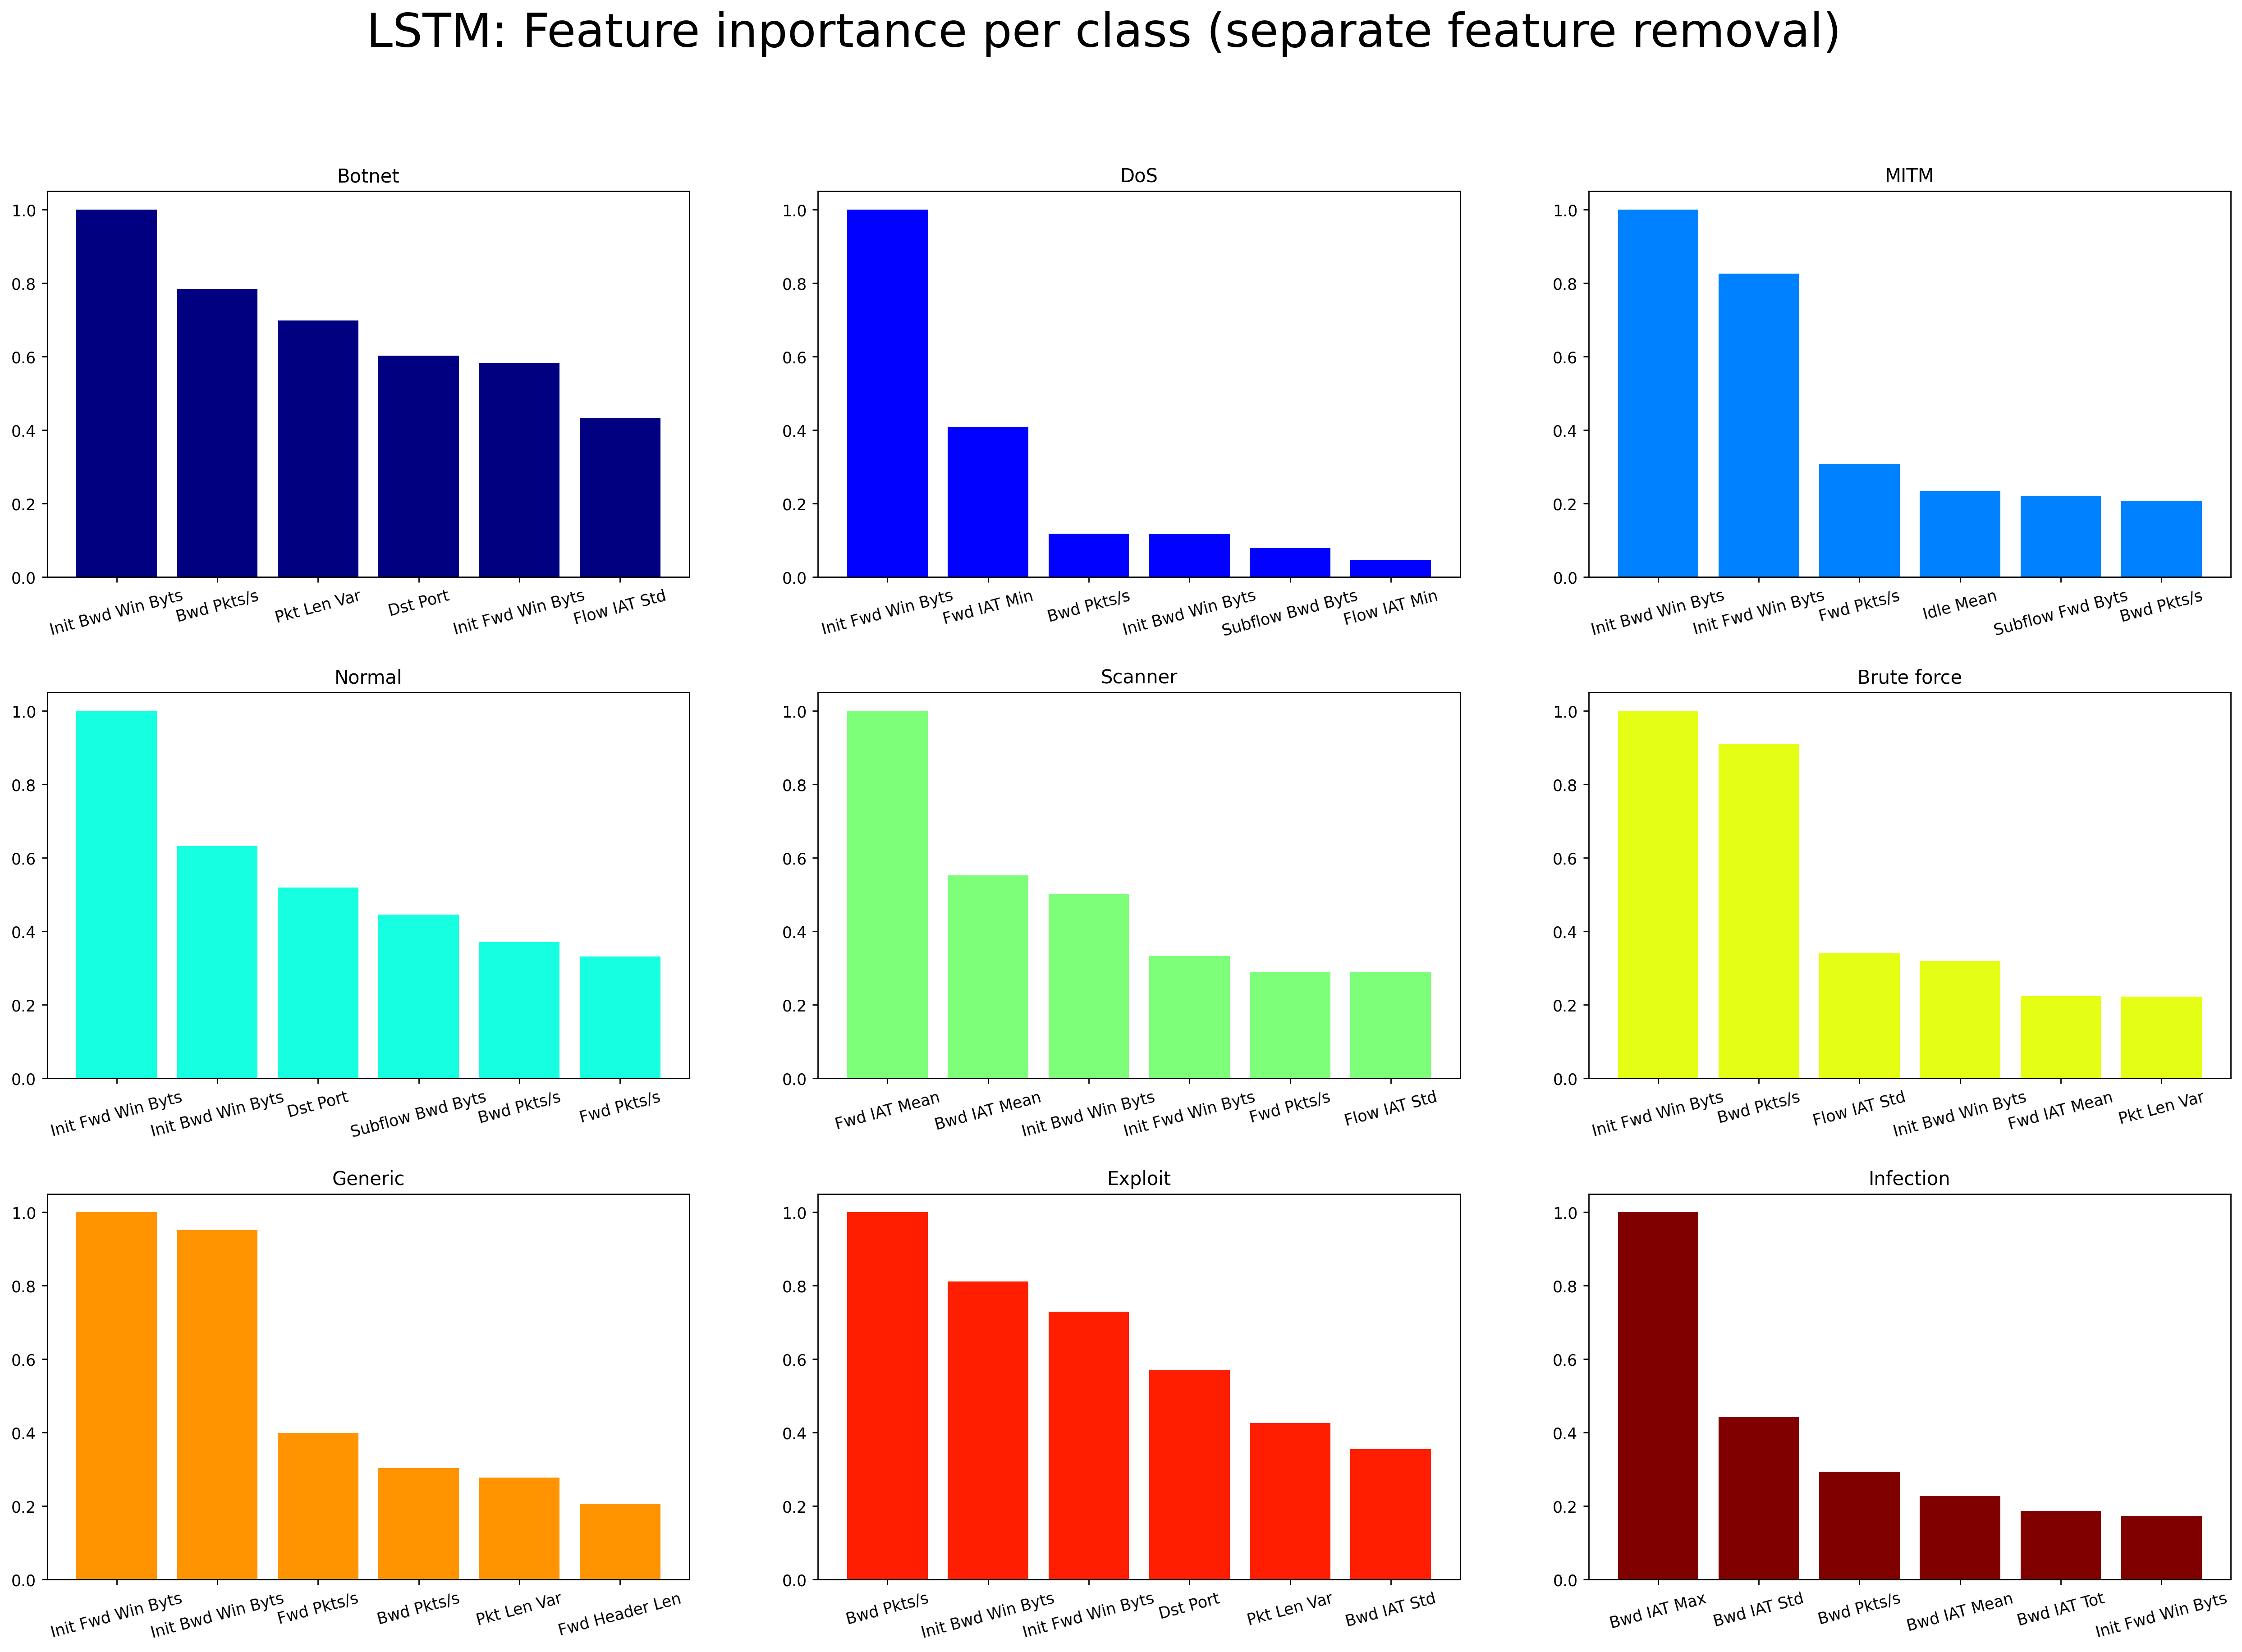

In [9]:
plot_shap_values(pd.read_csv(LSTM_SEP_REMOVED_SHAP_VALUES), "LSTM: Feature inportance per class (separate feature removal)")